In [94]:
# Plot river discharge USGS data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = 'usgs/Neuse_02091814_2017_2019_15min.txt' # Neuse
path2 = 'usgs/Tar_02084000_2017_2019_15min.txt' # Tar-Pamlico

df = pd.read_csv(path, sep='\t', skiprows=24)
df2 = pd.read_csv(path2, sep='\t', skiprows=25)

df = df.drop(index=0)
df2 = df2.drop(index=0)

print(df)
print(df2)

      agency_cd   site_no          datetime tz_cd 89299_00060 89299_00060_cd
1          USGS  02091814  2017-12-30 00:00   EST        1340              A
2          USGS  02091814  2017-12-30 00:15   EST        1330              A
3          USGS  02091814  2017-12-30 00:30   EST        1340              A
4          USGS  02091814  2017-12-30 00:45   EST        1320              A
5          USGS  02091814  2017-12-30 01:00   EST        1320              A
...         ...       ...               ...   ...         ...            ...
67045      USGS  02091814  2020-01-01 04:45   EST        2940            A:e
67046      USGS  02091814  2020-01-01 08:45   EST        2900            A:e
67047      USGS  02091814  2020-01-01 12:45   EST        2880            A:e
67048      USGS  02091814  2020-01-01 16:45   EST        2860            A:e
67049      USGS  02091814  2020-01-01 20:45   EST        2850            A:e

[67049 rows x 6 columns]
      agency_cd   site_no          datetime tz_cd 

In [95]:
# make a timeseries of Discharge for (1) Neuse and Pamlico and (2) Chowan and Roanoke (???)

tN = np.asarray(pd.to_datetime(df.iloc[:, 2]))
dN = np.asarray(df.iloc[:, 4]) 

tT = np.asarray(pd.to_datetime(df2.iloc[:, 2]))
dT = np.asarray(df2.iloc[:, 4]) 

start_date = pd.to_datetime('2019-01-01')
index = np.where(tN == start_date)[0]
start = index[0]

if index.size > 0:
    print(f"Index of datetime 1/1/2019: {index[0]}")
else:
    print("Datetime 1/1/2019 not found in the array.")

end = len(tN)
tN = tN[start:end]
dN = dN[start:end]

tT = tT[start:end]
dT = dT[start:end]
#min_dN = int(np.min(dN))
#max_dN = int(np.max(dN))
#print(min(dN), max_dN)

Index of datetime 1/1/2019: 33481


"\nplt.figure(figsize=(10, 5))\nplt.plot(t, d, marker='o', linestyle='-')\nplt.xlabel('Time')\nplt.ylabel('River Discharge (cfs)')\nplt.title('Neuse River Discharge 2018 - 2019')\nplt.xticks(rotation=45)  \nplt.set_ylabel('Floats')\n\nplt.savefig('discharge_plots_2019.png', format='png')\n"

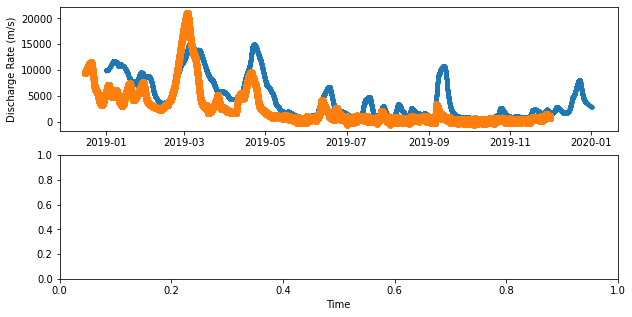

In [97]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(tN, np.asarray(dN,float),marker='.')
ax[0].tick_params(axis='x')
ax[0].set_ylabel('Discharge Rate (m/s)')

ax[0].plot(tT, np.asarray(dT,float),marker='o')
ax[1].set_xlabel('Time')


'''
plt.figure(figsize=(10, 5))
plt.plot(t, d, marker='o', linestyle='-')
plt.xlabel('Time')
plt.ylabel('River Discharge (cfs)')
plt.title('Neuse River Discharge 2018 - 2019')
plt.xticks(rotation=45)  
plt.set_ylabel('Floats')

plt.savefig('discharge_plots_2019.png', format='png')
'''